In [2]:
import json, glob
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ============================================================
# 1. Load all scored idea files
# ============================================================
scored_files = glob.glob("scored_*.json")
print(f"Found {len(scored_files)} files")

records = []
for path in scored_files:
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    fname = path.lower()
    mfam = "doubao" if "doubao" in fname else ("gemini" if "gemini" in fname else "openai")
    for r in data.get("records", []):
        if r.get("status") != "success":
            continue
        score = r.get("idea_count")
        if score is None:
            continue
        records.append({
            "model":         mfam,
            "role":          r.get("role", "unknown"),
            "responsibility":r.get("responsibility", "unknown"),
            "dilemma":       r.get("dilemma", "unknown"),
            "score":         float(score),
        })

df = pd.DataFrame(records)
print(f"Total valid records: {len(df)}")
print(f"Score range: {df['score'].min()} – {df['score'].max()},  mean={df['score'].mean():.3f}")
print(f"model:          {sorted(df['model'].unique())}")
print(f"role:           {sorted(df['role'].unique())}")
print(f"responsibility: {sorted(df['responsibility'].unique())}")

# ============================================================
# 2. Build interaction variables
# ============================================================
df["model_role"]  = df["model"] + "__" + df["role"]
df["model_resp"]  = df["model"] + "__" + df["responsibility"]
df["role_resp"]   = df["role"]  + "__" + df["responsibility"]
df["_group"]      = "all"   # single dummy group for crossed random effects

# ============================================================
# 3. Fit LMM (REML)
#    All 6 variance components go into vc_formula.
#    groups="_group" (single level) only provides residual structure.
#
#   Y = μ + α_model + β_role + γ_resp
#       + (αβ)_model×role + (αγ)_model×resp + (βγ)_role×resp + ε
# ============================================================
VC_KEYS = ["model", "role", "responsibility",
           "model_role", "model_resp", "role_resp"]

lmm = smf.mixedlm(
    "score ~ 1",
    data=df,
    groups=df["_group"],
    vc_formula={k: f"0 + C({k})" for k in VC_KEYS},
)
res = lmm.fit(reml=True, method="lbfgs")
print("\n" + "="*65)
print("  LMM (REML) — Variance Components")
print("  Y = μ + model + role + resp + model×role + model×resp + role×resp + ε")
print("="*65)
print(res.summary())

# ============================================================
# 4. Extract variance components & ICC
#    vcomp order follows VC_KEYS
# ============================================================
COMP_LABELS = {
    "model":      "model (α_m)",
    "role":       "role (β_r)",
    "resp":       "responsibility (γ_s)",
    "model_role": "model×role",
    "model_resp": "model×resp",
    "role_resp":  "role×resp",
    "within":     "within (ε)",
}

def get_varcomps(fitted):
    sigma2 = {}
    for i, k in enumerate(["model", "role", "resp",
                            "model_role", "model_resp", "role_resp"]):
        sigma2[k] = max(float(fitted.vcomp[i]), 0.0)   # clamp negatives to 0
    sigma2["within"] = float(fitted.scale)
    total = sum(sigma2.values())
    icc   = {k: (v / total if total > 0 else np.nan) for k, v in sigma2.items()}
    sigma2["total"] = total
    icc["total"]    = total
    return sigma2, icc

# fix VC_KEYS index mapping (resp is index 2 in VC_KEYS)
def get_varcomps(fitted):
    sigma2 = {}
    vc_map = {"model": 0, "role": 1, "resp": 2,
               "model_role": 3, "model_resp": 4, "role_resp": 5}
    for k, i in vc_map.items():
        sigma2[k] = max(float(fitted.vcomp[i]), 0.0)
    sigma2["within"] = float(fitted.scale)
    total = sum(sigma2.values())
    icc   = {k: (v / total if total > 0 else np.nan) for k, v in sigma2.items()}
    sigma2["total"] = total
    icc["total"]    = total
    return sigma2, icc

sigma2, icc = get_varcomps(res)

print("\n--- Variance Components & ICC (point estimates) ---")
vc_pt = pd.DataFrame({
    "σ²":  [sigma2[k] for k in list(COMP_LABELS)] + [sigma2["total"]],
    "ICC": [icc[k]    for k in list(COMP_LABELS)] + [1.0],
}, index=list(COMP_LABELS.values()) + ["Total"])
display(vc_pt.round(4))


Found 9 files
Total valid records: 2502
Score range: 2.0 – 5.0,  mean=3.598
model:          ['doubao', 'gemini', 'openai']
role:           ['role_A', 'role_B', 'role_C', 'role_D', 'role_E', 'role_F', 'role_G']
responsibility: ['neutral', 'not_responsible', 'responsible']

  LMM (REML) — Variance Components
  Y = μ + model + role + resp + model×role + model×resp + role×resp + ε
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  score     
No. Observations:   2502     Method:              REML      
No. Groups:         1        Scale:               0.2835    
Min. group size:    2502     Log-Likelihood:      -2018.4389
Max. group size:    2502     Converged:           Yes       
Mean group size:    2502.0                                  
------------------------------------------------------------
                   Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          3.5

c:\Users\lenovo\anaconda3\envs\myenv\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,σ²,ICC
model (α_m),0.0168,0.0469
role (β_r),0.0078,0.0217
responsibility (γ_s),0.0324,0.0902
model×role,0.0028,0.0079
model×resp,0.0132,0.0368
role×resp,0.0024,0.0067
within (ε),0.2835,0.7899
Total,0.3589,1.0000


In [3]:

# ============================================================
# 5. Stratified Bootstrap CI (500 iterations)
# ============================================================
N_BOOT = 500
SEED   = 42
rng    = np.random.default_rng(SEED)

boot_icc = {k: [] for k in COMP_LABELS}
cells    = df.groupby(["model", "role", "responsibility"])

for b in range(N_BOOT):
    parts = []
    for _, cell_df in cells:
        n   = len(cell_df)
        idx = rng.integers(0, n, size=n)
        parts.append(cell_df.iloc[idx])
    df_b = pd.concat(parts, ignore_index=True)
    df_b["model_role"] = df_b["model"] + "__" + df_b["role"]
    df_b["model_resp"] = df_b["model"] + "__" + df_b["responsibility"]
    df_b["role_resp"]  = df_b["role"]  + "__" + df_b["responsibility"]
    df_b["_group"]     = "all"

    try:
        res_b = smf.mixedlm(
            "score ~ 1",
            data=df_b,
            groups=df_b["_group"],
            vc_formula={k: f"0 + C({k})" for k in VC_KEYS},
        ).fit(reml=True, method="lbfgs", disp=False)
        _, icc_b = get_varcomps(res_b)
        for k in boot_icc:
            boot_icc[k].append(icc_b[k])
    except Exception:
        pass

print(f"\nBootstrap: {len(boot_icc['model'])} / {N_BOOT} iterations converged")

# ============================================================
# 6. Final ICC table with 95% CI
# ============================================================
rows = []
for k, label in COMP_LABELS.items():
    vals = np.array(boot_icc[k])
    ci_lo, ci_hi = (np.percentile(vals, [2.5, 97.5]) if len(vals) > 0
                    else (np.nan, np.nan))
    rows.append({
        "Component": label,
        "σ²":        round(sigma2[k], 4),
        "ICC":       round(icc[k], 4),
        "CI lower":  round(float(ci_lo), 4),
        "CI upper":  round(float(ci_hi), 4),
    })

icc_table = pd.DataFrame(rows)
print("\n=== ICC Summary — 95% Bootstrap CI (1,000 iterations) ===\n")
display(icc_table)
icc_table.to_csv("icc_variance_components.csv", index=False, encoding="utf-8-sig")
print("Saved: icc_variance_components.csv")


c:\Users\lenovo\anaconda3\envs\myenv\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\lenovo\anaconda3\envs\myenv\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\lenovo\anaconda3\envs\myenv\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\lenovo\anaconda3\envs\myenv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\lenovo\anaconda3\envs\myenv\lib\site-packages\statsmodels\regres


Bootstrap: 200 / 200 iterations converged

=== ICC Summary — 95% Bootstrap CI (1,000 iterations) ===



c:\Users\lenovo\anaconda3\envs\myenv\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,Component,σ²,ICC,CI lower,CI upper
0,model (α_m),0.0168,0.0469,0.0232,0.2287
1,role (β_r),0.0078,0.0217,0.0091,0.1048
2,responsibility (γ_s),0.0324,0.0902,0.0266,0.1650
3,model×role,0.0028,0.0079,0.0000,0.2241
4,model×resp,0.0132,0.0368,0.0005,0.1455
5,role×resp,0.0024,0.0067,0.0013,0.0265
6,within (ε),0.2835,0.7899,0.2721,0.8096


Saved: icc_variance_components.csv


P1: Use Claude Opus 4.6 to count the number of ideas in each reasoning section as a creativity score.

We decompose the total variance in creativity scores using a linear mixed effects model. For creativity score $Y_{mrs}$ (model $m$, role $r$, responsibility condition $s$), the model specification is:

$$Y_{mrs} = \mu + \alpha_m + \beta_r + \gamma_s + (\alpha\beta)_{mr} + (\alpha\gamma)_{ms} + (\beta\gamma)_{rs} + \epsilon_{mrs} \tag{1}$$

where $\mu$ is the overall mean; $\alpha_m \sim \mathcal{N}(0, \sigma^2_{\text{model}})$ is the random intercept for each LLM; $\beta_r \sim \mathcal{N}(0, \sigma^2_{\text{role}})$ is the random intercept for each role prompt; $\gamma_s \sim \mathcal{N}(0, \sigma^2_{\text{resp}})$ is the random intercept for each responsibility condition; $(\alpha\beta)_{mr}$, $(\alpha\gamma)_{ms}$, $(\beta\gamma)_{rs}$ are the pairwise interaction random effects for model×role, model×responsibility, and role×responsibility respectively; $\epsilon_{mrs} \sim \mathcal{N}(0, \sigma^2_{\text{within}})$ is the within-group error capturing random variation from temperature sampling.

Model parameters are estimated using Restricted Maximum Likelihood (REML). Variance components are reported as Intraclass Correlation Coefficients (ICC), reflecting the proportion of total variance explained by each factor (Bliese, 2000). 95% confidence intervals are computed via stratified bootstrap resampling (1,000 iterations) within model–role–responsibility cells.

Using existing df: 2502 rows


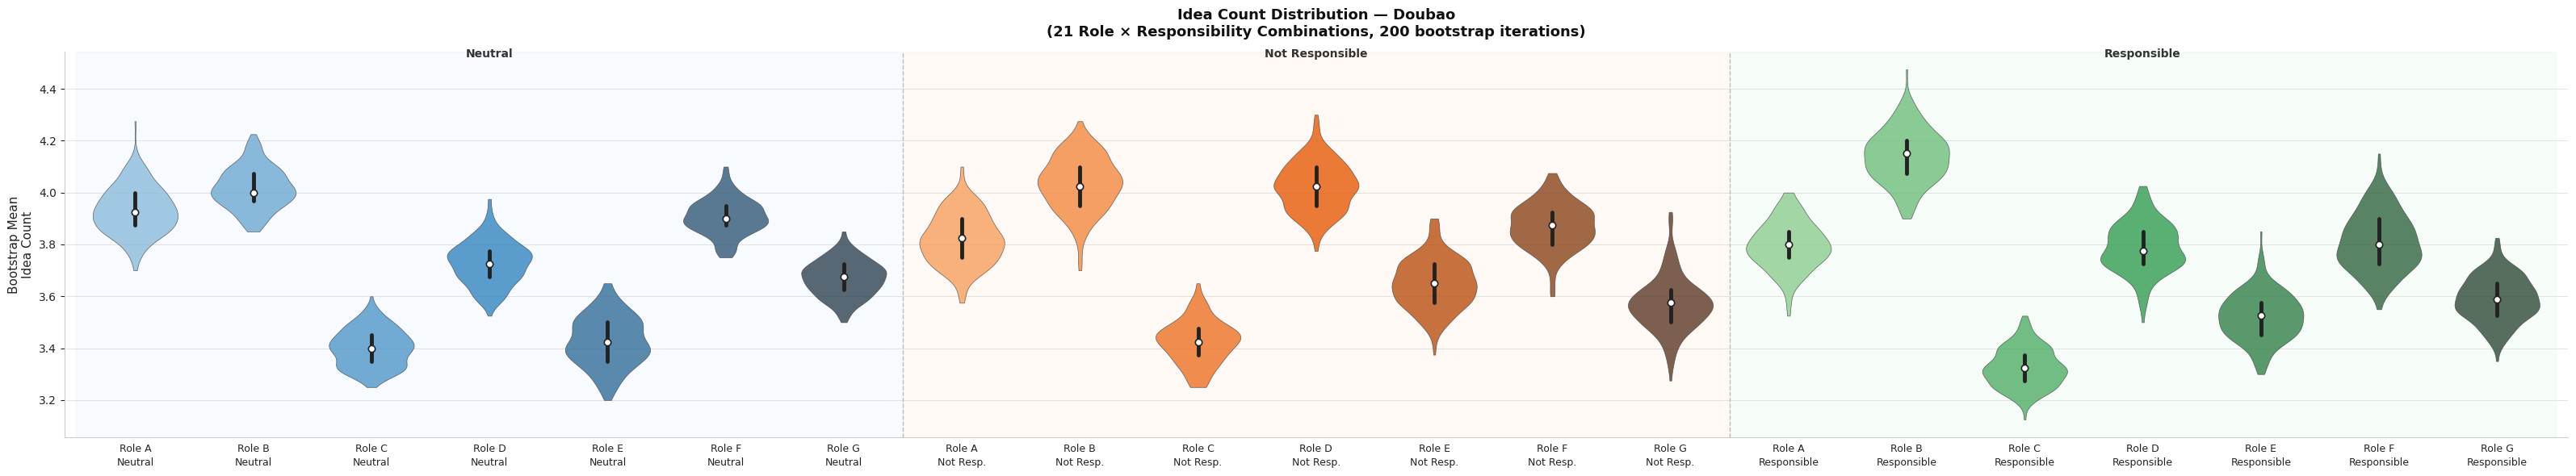

Saved: violin_ideas_doubao.png


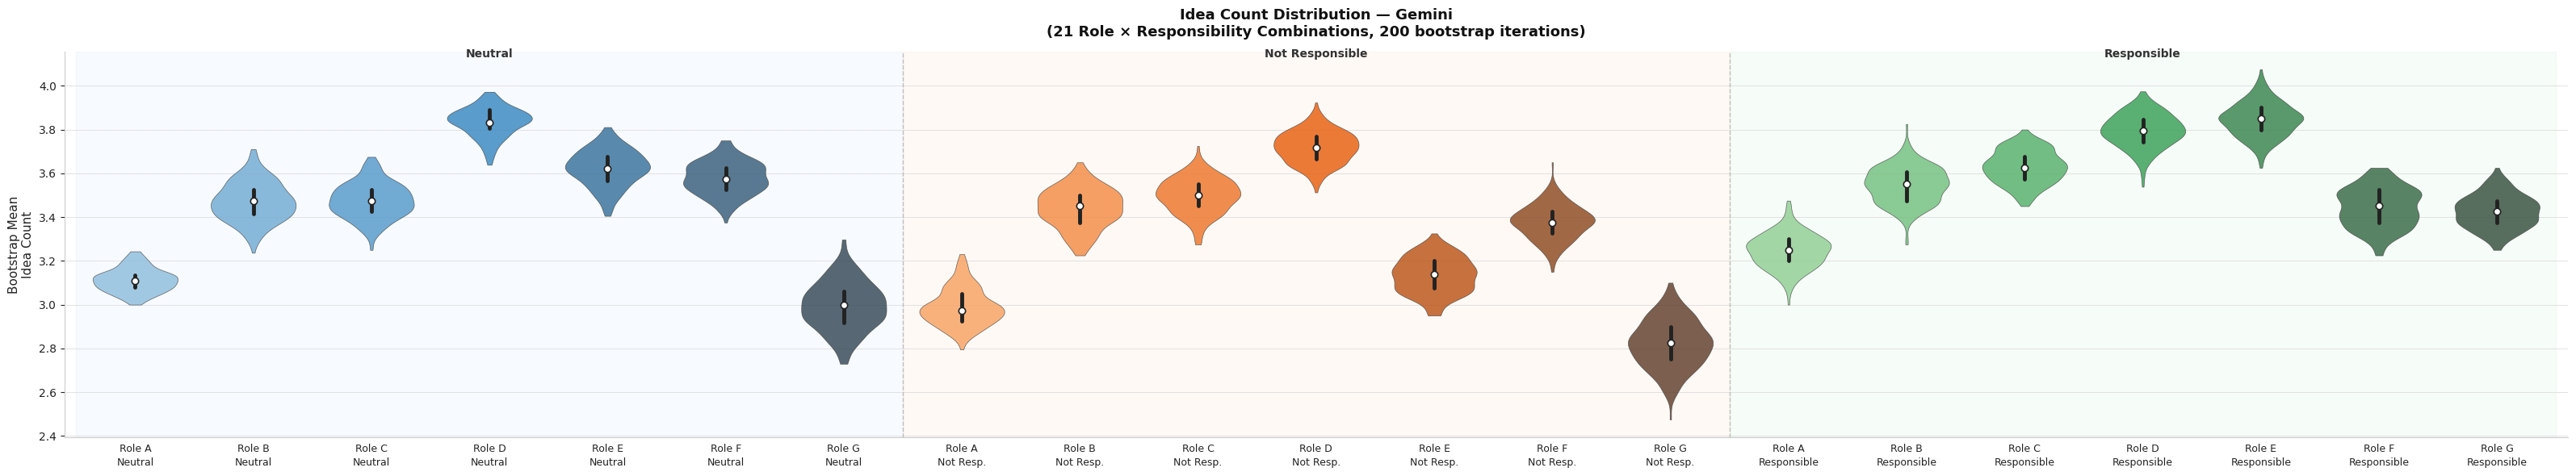

Saved: violin_ideas_gemini.png


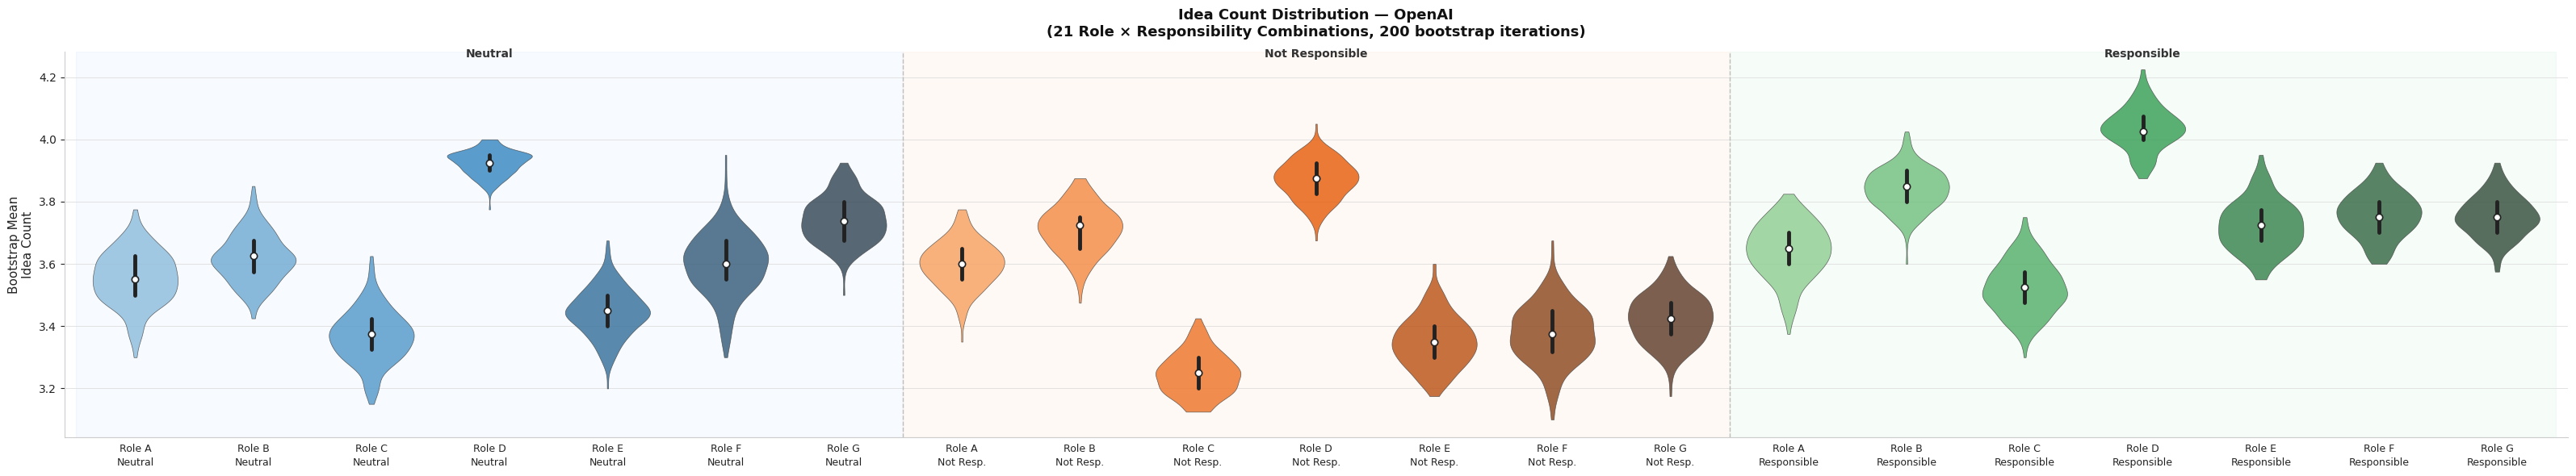

Saved: violin_ideas_openai.png


In [5]:
import json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Load data
# ============================================================
try:
    df
    print(f"Using existing df: {len(df)} rows")
except NameError:
    scored_files = glob.glob("scored_*.json")
    records = []
    for path in scored_files:
        with open(path, encoding="utf-8") as f:
            data = json.load(f)
        fname = path.lower()
        mfam = "doubao" if "doubao" in fname else ("gemini" if "gemini" in fname else "openai")
        for r in data.get("records", []):
            if r.get("status") != "success": continue
            score = r.get("idea_count")
            if score is None: continue
            records.append({
                "model":          mfam,
                "role":           r.get("role"),
                "responsibility": r.get("responsibility"),
                "score":          float(score),
            })
    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} rows")

# ============================================================
# 2. Bootstrap: 200 iterations per (model, role, responsibility)
# ============================================================
N_BOOT = 200
SEED   = 42
rng    = np.random.default_rng(SEED)

ROLE_ORDER = ["role_A","role_B","role_C","role_D","role_E","role_F","role_G"]
RESP_ORDER = ["neutral","not_responsible","responsible"]
ROLE_LABEL = {"role_A":"Role A","role_B":"Role B","role_C":"Role C","role_D":"Role D",
              "role_E":"Role E","role_F":"Role F","role_G":"Role G"}
RESP_LABEL = {"neutral":"Neutral","not_responsible":"Not Resp.","responsible":"Responsible"}

boot_records = []
for (model, role, resp), grp in df.groupby(["model","role","responsibility"]):
    vals = grp["score"].values
    for _ in range(N_BOOT):
        sample = rng.choice(vals, size=len(vals), replace=True)
        boot_records.append({
            "model": model, "role": role, "responsibility": resp,
            "boot_mean": float(sample.mean()),
        })

boot_df = pd.DataFrame(boot_records)

# ============================================================
# 3. Combos & labels
# ============================================================
combos    = [(resp, role) for resp in RESP_ORDER for role in ROLE_ORDER]
combo_idx = {c: i for i, c in enumerate(combos)}

# two-line label: role on top, resp below
combo_label = {(resp, role): f"{ROLE_LABEL[role]}\n{RESP_LABEL[resp]}"
               for resp, role in combos}

boot_df["combo"] = list(zip(boot_df["responsibility"], boot_df["role"]))
boot_df["x_idx"] = boot_df["combo"].map(combo_idx)

# ============================================================
# 4. Colours — muted palette, one hue per responsibility group
# ============================================================
RESP_PALETTE = {
    "neutral":         sns.color_palette("Blues_d",  7),
    "not_responsible": sns.color_palette("Oranges_d",7),
    "responsible":     sns.color_palette("Greens_d", 7),
}
combo_color = {(resp, role): RESP_PALETTE[resp][ri]
               for resp in RESP_ORDER
               for ri, role in enumerate(ROLE_ORDER)}

# ============================================================
# 5. Plot — white background, larger figure, clear labels
# ============================================================
MODELS       = sorted(df["model"].unique())
MODEL_TITLES = {"doubao":"Doubao", "gemini":"Gemini", "openai":"OpenAI"}

for model in MODELS:
    sub = boot_df[boot_df["model"] == model].sort_values("x_idx")

    fig, ax = plt.subplots(figsize=(32, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    x_positions = sorted(sub["x_idx"].unique())
    for xi in x_positions:
        cell  = sub[sub["x_idx"] == xi]["boot_mean"].values
        color = combo_color[combos[xi]]

        parts = ax.violinplot(cell, positions=[xi], widths=0.72,
                              showmedians=False, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor("#444444")
            pc.set_alpha(0.82)
            pc.set_linewidth(0.5)

        q25, med, q75 = np.percentile(cell, [25, 50, 75])
        ax.plot([xi, xi], [q25, q75], color="#222222", lw=3.5,
                solid_capstyle="round", zorder=3)
        ax.plot(xi, med, "o", color="white", markeredgecolor="#222222",
                markersize=6, markeredgewidth=1.2, zorder=4)

    # x-axis labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels([combo_label[combos[xi]] for xi in x_positions],
                       fontsize=9, color="#222222", linespacing=1.4)
    ax.tick_params(axis="x", which="both", length=0, pad=6)
    ax.tick_params(axis="y", colors="#222222", labelsize=10)

    ax.set_ylabel("Bootstrap Mean\nIdea Count", color="#222222", fontsize=11)
    ax.set_title(
        f"Idea Count Distribution — {MODEL_TITLES.get(model, model)}\n"
        f"(21 Role × Responsibility Combinations, {N_BOOT} bootstrap iterations)",
        color="#111111", fontsize=13, pad=14, fontweight="bold")

    # separator lines & group header bands
    for gi, (resp, label) in enumerate(zip(RESP_ORDER,
                                           ["Neutral","Not Responsible","Responsible"])):
        x_lo, x_hi = gi * 7 - 0.5, gi * 7 + 6.5
        ax.axvspan(x_lo, x_hi, alpha=0.04,
                   color=["#3b82f6","#f97316","#22c55e"][gi], zorder=0)
        ax.text((x_lo + x_hi) / 2, 0.98, label,
                ha="center", va="bottom", color="#333333",
                fontsize=10, fontweight="bold",
                transform=ax.get_xaxis_transform())

    for sep in [6.5, 13.5]:
        ax.axvline(sep, color="#aaaaaa", lw=1.0, linestyle="--", alpha=0.7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.set_xlim(-0.6, 20.6)

    plt.tight_layout()
    out = f"violin_ideas_{model}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {out}")


In [ ]:
# ============================================================
# Average delta in idea count: responsible vs not_responsible
# ============================================================
_means = (
    df[df['responsibility'].isin(['responsible', 'not_responsible'])]
    .groupby(['model', 'role', 'responsibility'])['score']
    .mean()
    .unstack('responsibility')          # cols: not_responsible | responsible
)

_means['delta'] = _means['responsible'] - _means['not_responsible']

print('=== Delta (responsible − not_responsible) per model × role ===')
print(_means['delta'].unstack('model').round(3).to_string())

overall = _means['delta'].mean()
by_model = _means['delta'].groupby('model').mean()
by_role  = _means['delta'].groupby('role').mean()

print(f'
Overall mean delta : {overall:+.4f} ideas')
print('
By model:')
for m, v in by_model.items():
    print(f'  {m:<10} {v:+.4f}')
print('
By role:')
for r, v in by_role.items():
    print(f'  {r:<8} {v:+.4f}')


In [ ]:
# ============================================================
# Average delta in idea count: responsible vs neutral
# ============================================================
_means2 = (
    df[df['responsibility'].isin(['responsible', 'neutral'])]
    .groupby(['model', 'role', 'responsibility'])['score']
    .mean()
    .unstack('responsibility')          # cols: neutral | responsible
)

_means2['delta'] = _means2['responsible'] - _means2['neutral']

print('=== Delta (responsible − neutral) per model × role ===')
print(_means2['delta'].unstack('model').round(3).to_string())

overall2 = _means2['delta'].mean()
by_model2 = _means2['delta'].groupby('model').mean()
by_role2  = _means2['delta'].groupby('role').mean()

print(f'
Overall mean delta : {overall2:+.4f} ideas')
print('
By model:')
for m, v in by_model2.items():
    print(f'  {m:<10} {v:+.4f}')
print('
By role:')
for r, v in by_role2.items():
    print(f'  {r:<8} {v:+.4f}')
